# loading dataset

In [3]:
import os
import numpy as np
import nibabel as nib
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import tensorflow as tf
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from nilearn.image import resample_img
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation
from matplotlib import pyplot as plt

In [ ]:
# --- SETTINGS ---
TARGET_SHAPE = (128, 128, 128)
N_CLASSES = 3
BATCH_SIZE = 4

# --- Utility functions ---
def reorient_to_ras(data, affine):
    current_ornt = io_orientation(affine)
    ras_ornt = axcodes2ornt(('R','A','S'))
    transform = ornt_transform(current_ornt, ras_ornt)
    return apply_orientation(data, transform)

def preprocess_sample(image_path, mask_path, target_shape=TARGET_SHAPE, n_classes=N_CLASSES, visualize=False):
    # Load NIfTI
    image_path = image_path.numpy().decode()
    mask_path = mask_path.numpy().decode()
    
    img_nii = nib.load(image_path)
    mask_nii = nib.load(mask_path)
    
    # Resample mask to image affine
    mask_resampled_nii = resample_img(
        mask_nii, 
        target_affine=img_nii.affine, 
        target_shape=img_nii.shape,
        interpolation='nearest'
    )
    
    # Reorient to RAS
    img_ras = reorient_to_ras(img_nii.get_fdata(), img_nii.affine)
    mask_ras = reorient_to_ras(mask_resampled_nii.get_fdata(), mask_resampled_nii.affine)
    
    # Resize to target shape
    if img_ras.shape != target_shape:
        img_ras = resize(img_ras, target_shape, preserve_range=True)
    if mask_ras.shape != target_shape:
        mask_ras = resize(mask_ras, target_shape, order=0, preserve_range=True)
    
    # Normalize image
    img_ras = (img_ras - img_ras.min()) / (img_ras.max() - img_ras.min())
    img_ras = np.expand_dims(img_ras, axis=-1)
    
    # Round mask values and one-hot encode
    mask_ras = np.rint(mask_ras).astype(np.int32)
    mask_ras = tf.keras.utils.to_categorical(mask_ras, num_classes=n_classes)
    
    # Optional visualization (debugging)
    if visualize:
        mid_sagittal = img_ras.shape[0] // 2
        mid_coronal = img_ras.shape[1] // 2
        mid_axial = img_ras.shape[2] // 2
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.title('Sagittal')
        plt.imshow(img_ras[mid_sagittal, :, :, 0].T, cmap='gray', origin='lower')
        plt.imshow(mask_ras[mid_sagittal, :, :, :].argmax(axis=-1).T, alpha=0.3, cmap='viridis', origin='lower')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.title('Coronal')
        plt.imshow(img_ras[:, mid_coronal, :, 0].T, cmap='gray', origin='lower')
        plt.imshow(mask_ras[:, mid_coronal, :, :].argmax(axis=-1).T, alpha=0.3, cmap='viridis', origin='lower')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.title('Axial')
        plt.imshow(img_ras[:, :, mid_axial, 0].T, cmap='gray', origin='lower')
        plt.imshow(mask_ras[:, :, mid_axial, :].argmax(axis=-1).T, alpha=0.3, cmap='viridis', origin='lower')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return img_ras.astype(np.float32), mask_ras.astype(np.float32)

def tf_preprocess(image_path, mask_path):
    img, mask = tf.py_function(func=preprocess_sample,
                               inp=[image_path, mask_path],
                               Tout=[tf.float32, tf.float32])
    img.set_shape(TARGET_SHAPE + (1,))
    mask.set_shape(TARGET_SHAPE + (N_CLASSES,))
    return img, mask

def create_dataset(image_dir, mask_dir, batch_size=BATCH_SIZE, shuffle=True):
    image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir)])
    mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))
    dataset = dataset.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# --- Paths ---
train_image_dir = "MRIs_SPLIT/train/images"
train_mask_dir = "MRIs_SPLIT/train/masks"
val_image_dir = "MRIs_SPLIT/val/images"
val_mask_dir = "MRIs_SPLIT/val/masks"
test_image_dir = "MRIs_SPLIT/test/images"
test_mask_dir = "MRIs_SPLIT/test/masks"

# --- Datasets ---
train_dataset = create_dataset(train_image_dir, train_mask_dir)
val_dataset = create_dataset(val_image_dir, val_mask_dir, shuffle=False)
test_dataset = create_dataset(test_image_dir, test_mask_dir, shuffle=False)

# building the model from [3D MRI Segmentation using U-Net Architecture for the detection of Brain Tumor](https://drive.google.com/file/d/1WXskRoVNTbn7Fj0hHP5-fKyXk7fl6_Z7/view?usp=sharing)

In [8]:
def build_unet3d(input_shape=(128,128,128,1), n_classes=N_CLASSES):
    inputs = layers.Input(input_shape)

    # ----------------------
    # Encoder
    # ----------------------
    # Level 1
    c1 = layers.Conv3D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling3D(2)(c1)

    # Level 2
    c2 = layers.Conv3D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv3D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling3D(2)(c2)

    # Level 3
    c3 = layers.Conv3D(128, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv3D(128, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling3D(2)(c3)

    # Level 4
    c4 = layers.Conv3D(256, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv3D(256, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling3D(2)(c4)

    # Bottleneck
    c5 = layers.Conv3D(512, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv3D(512, 3, activation='relu', padding='same')(c5)

    # ----------------------
    # Decoder
    # ----------------------
    # Level 4
    u4 = layers.UpSampling3D(2)(c5)
    u4 = layers.Concatenate()([u4, c4])
    c6 = layers.Conv3D(256, 3, activation='relu', padding='same')(u4)
    c6 = layers.Conv3D(256, 3, activation='relu', padding='same')(c6)

    # Level 3
    u3 = layers.UpSampling3D(2)(c6)
    u3 = layers.Concatenate()([u3, c3])
    c7 = layers.Conv3D(128, 3, activation='relu', padding='same')(u3)
    c7 = layers.Conv3D(128, 3, activation='relu', padding='same')(c7)

    # Level 2
    u2 = layers.UpSampling3D(2)(c7)
    u2 = layers.Concatenate()([u2, c2])
    c8 = layers.Conv3D(64, 3, activation='relu', padding='same')(u2)
    c8 = layers.Conv3D(64, 3, activation='relu', padding='same')(c8)

    # Level 1
    u1 = layers.UpSampling3D(2)(c8)
    u1 = layers.Concatenate()([u1, c1])
    c9 = layers.Conv3D(32, 3, activation='relu', padding='same')(u1)
    c9 = layers.Conv3D(32, 3, activation='relu', padding='same')(c9)

    # Output
    outputs = layers.Conv3D(n_classes, 1, activation='softmax')(c9)

    # Model
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

# training

In [9]:
model = build_unet3d(input_shape=(128,128,128,1), n_classes=N_CLASSES)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 128, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d (Conv3D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d       │ (None, 64, 64,    │          0 │ conv3d[0][0]      │
│ (MaxPooling3D)      │ 64, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 64, 64,    │     55,360 │ max_pooling3d[0]… │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 64, 64,    │    110,656 │ conv3d_1[0][0]    │
│                     │ 64, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_1     │ (None, 32, 32,    │          0 │ conv3d_2[0][0]    │
│ (MaxPooling3D)      │ 32, 64)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_3 (Conv3D)   │ (None, 32, 32,    │    221,312 │ max_pooling3d_1[… │
│                     │ 32, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_4 (Conv3D)   │ (None, 32, 32,    │    442,496 │ conv3d_3[0][0]    │
│                     │ 32, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_2     │ (None, 16, 16,    │          0 │ conv3d_4[0][0]    │
│ (MaxPooling3D)      │ 16, 128)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_5 (Conv3D)   │ (None, 16, 16,    │    884,992 │ max_pooling3d_2[… │
│                     │ 16, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_6 (Conv3D)   │ (None, 16, 16,    │  1,769,728 │ conv3d_5[0][0]    │
│                     │ 16, 256)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_3     │ (None, 8, 8, 8,   │          0 │ conv3d_6[0][0]    │
│ (MaxPooling3D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_7 (Conv3D)   │ (None, 8, 8, 8,   │  3,539,456 │ max_pooling3d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_8 (Conv3D)   │ (None, 8, 8, 8,   │  7,078,400 │ conv3d_7[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling3d       │ (None, 16, 16,    │          0 │ conv3d_8[0][0]    │
│ (UpSampling3D)      │ 16, 512)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling3d[0]… │
│ (Concatenate)       │ 16, 768)          │            │ conv3d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_9 (Conv3D)   │ (None, 16, 16,    │  5,308,672 │ concatenate[0][0

 Total params: 23,504,675 (89.66 MB)

 Trainable params: 23,504,675 (89.66 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
path_unet = "unet_outputs"

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from datetime import datetime
import pickle

# Save the best model (lowest val_loss) during training
checkpoint_cb = ModelCheckpoint(
    f"{path_unet}/unet3d_best_{datetime.now()}.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min",
    verbose=1
)

# Stop if validation loss doesn't improve for 10 epochs
earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,        # number of epochs with no improvement
    restore_best_weights=True,  # load back the best weights
    verbose=1
)

# initialize history variable
history = None
# Run training with callbacks
history = model.fit(
    train_dataset,
    validation_data=(val_dataset),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint_cb, earlystop_cb]
)

# Also save the final model
model.save(f"{path_unet}/unet3d_final_{datetime.now()}.keras")


Epoch 1/50


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

  1/133 ━━━━━━━━━━━━━━━━━━━━ 4:10:52 114s/step - accuracy: 0.2143 - loss: 1.1018

/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


  2/133 ━━━━━━━━━━━━━━━━━━━━ 4:19 2s/step - accuracy: 0.3921 - loss: 1.0287     

...

124/133 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9358 - loss: 0.1594

/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9357 - loss: 0.1595

/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w


Epoch 40: val_loss did not improve from 0.03186
133/133 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9353 - loss: 0.1604 - val_accuracy: 0.9380 - val_loss: 0.1552
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.


# testing

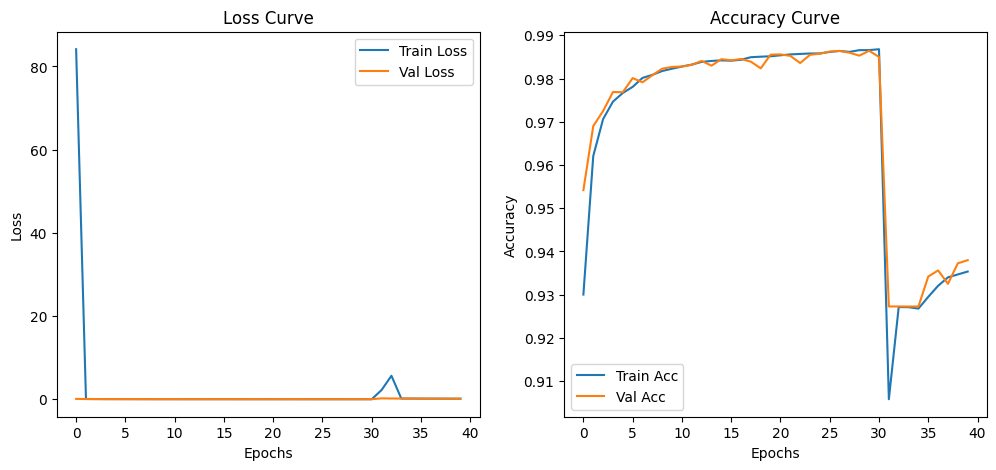

/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

Mean Dice: 0.9865512844552644
Mean IoU : 0.9734667279476124


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

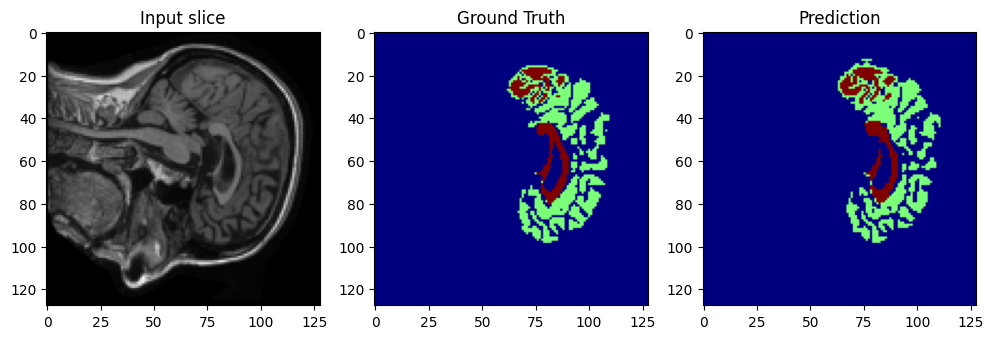

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf

# ------------------------------
# 1. Load best model
# ------------------------------
#model = keras.models.load_model("unet3d_best.keras")

# ------------------------------
# 2. Plot Training Curves
# ------------------------------
def plot_training_curves(history):
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    # Accuracy (if available)
    if "accuracy" in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history["accuracy"], label="Train Acc")
        plt.plot(history.history["val_accuracy"], label="Val Acc")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.title("Accuracy Curve")

    plt.show()

# If you have history from training
if history is not None:
    plot_training_curves(history)

# ------------------------------
# 3. Define metrics
# ------------------------------
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

# ------------------------------
# 4. Evaluate model on tf.data test dataset
# ------------------------------
def evaluate_model(model, test_dataset, threshold=0.5, max_batches=None):
    dices, ious = [], []

    for batch_idx, (X_batch, Y_batch) in enumerate(test_dataset):
        preds = model.predict(X_batch, verbose=0)
        preds = (preds > threshold).astype(np.uint8)

        for i in range(len(X_batch)):
            dices.append(dice_coefficient(Y_batch[i].numpy(), preds[i]))
            ious.append(iou_score(Y_batch[i].numpy(), preds[i]))

        if max_batches and batch_idx + 1 >= max_batches:
            break

    print("Mean Dice:", np.mean(dices))
    print("Mean IoU :", np.mean(ious))
    return dices, ious

# Example usage (evaluate only on 10 batches for speed):
dices, ious = evaluate_model(model, test_dataset, max_batches=10)

# ------------------------------
# 5. Visualize predictions
# ------------------------------
def visualize_prediction(model, test_dataset, idx=0, threshold=0.5):
    """Visualize one sample from test_dataset."""
    # Unbatch to access individual samples
    test_iter = test_dataset.unbatch().as_numpy_iterator()
    samples = []
    for i, (x, y) in enumerate(test_iter):
        if i == idx:
            sample, true_mask = x, y
            break

    # Predict
    pred = model.predict(np.expand_dims(sample, axis=0), verbose=0)
    pred_mask = np.argmax(np.squeeze(pred, axis=0), axis=-1).astype(np.uint8)

    true_mask = np.argmax(true_mask, axis=-1)

    # Pick middle slice
    slice_idx = sample.shape[0] // 2

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Input slice")
    plt.imshow(sample[slice_idx, :, :, 0], cmap="gray")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(true_mask[slice_idx, :, :], cmap="jet")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_mask[slice_idx, :, :], cmap="jet")
    plt.show()

# Example visualization
visualize_prediction(model, test_dataset, idx=0)


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

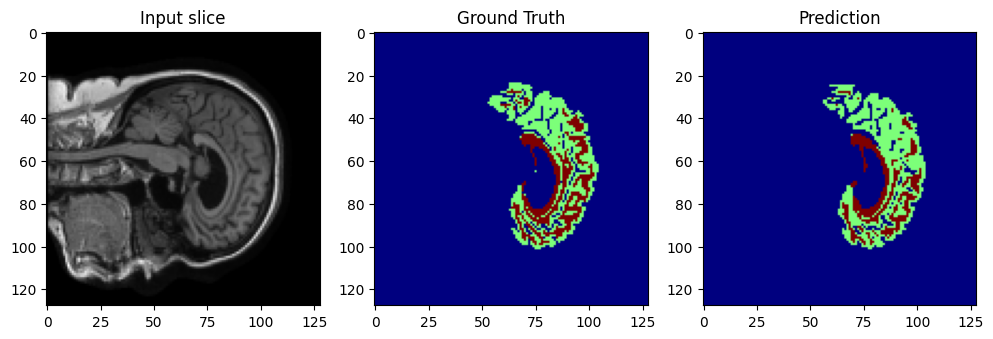

In [12]:
visualize_prediction(model, test_dataset, idx=70)


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

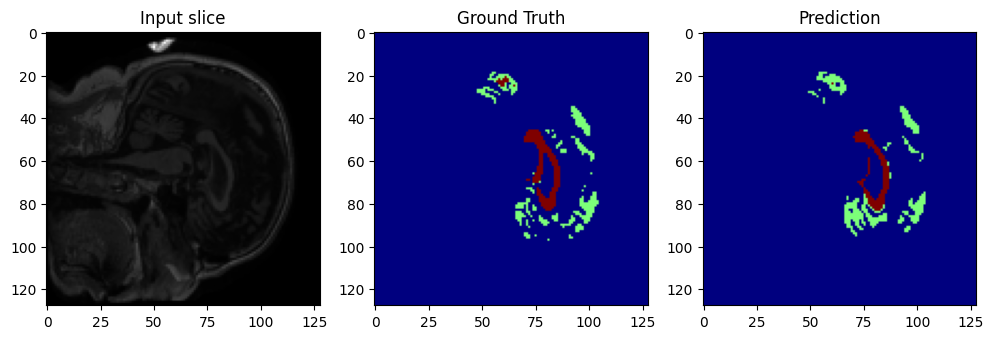

In [13]:
visualize_prediction(model, test_dataset, idx=50)


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

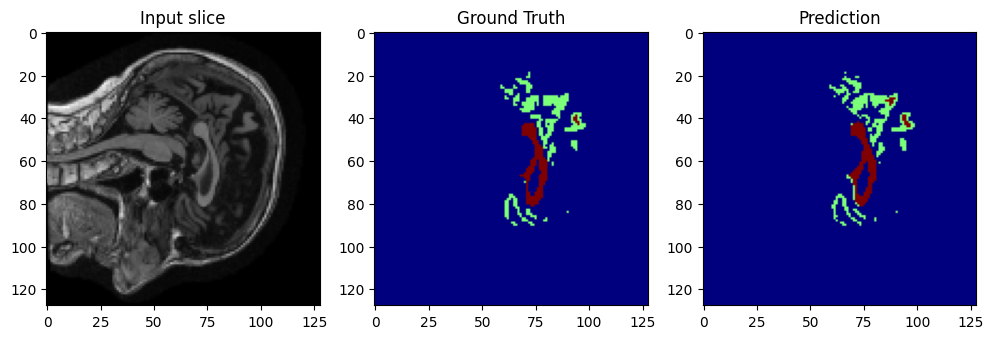

In [14]:
visualize_prediction(model, test_dataset, idx=42)


/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_5395/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this w

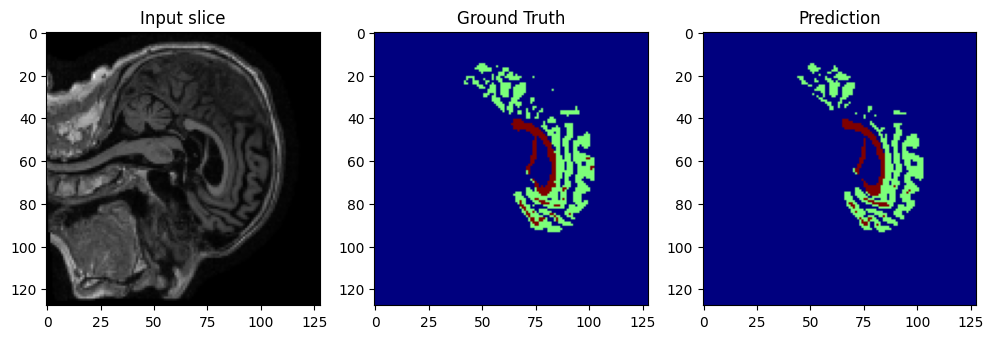

In [15]:
visualize_prediction(model, test_dataset, idx=11)


In [17]:
import tensorflow as tf
import numpy as np

def load_and_check_model(model_path, sample_img=None):
    """
    Load a trained model and verify its output configuration.

    Args:
        model_path (str): Path to the saved model (.h5 or SavedModel dir).
        sample_img (np.ndarray): Optional input image to test predictions.
                                 Shape should match model input (H,W,D,1).

    Returns:
        model (tf.keras.Model)
    """
    # Load model
    model = tf.keras.models.load_model(model_path, compile=False)
    print("✅ Model loaded from:", model_path)

    # Show summary
    model.summary()

    # Check final layer shape
    output_shape = model.output_shape
    print("🔎 Model output shape:", output_shape)

    if isinstance(output_shape, list):
        n_classes = output_shape[0][-1]
    else:
        n_classes = output_shape[-1]

    print(f"⚡ Detected number of output classes: {n_classes}")

    # Run a quick prediction check if sample provided
    if sample_img is not None:
        sample = np.expand_dims(sample_img, axis=0)  # add batch dim
        pred = model.predict(sample)
        unique_preds = np.unique(np.argmax(pred[0], axis=-1))
        print("🎯 Unique predicted classes in sample:", unique_preds)

    return model


In [18]:
# Suppose your model is saved as "unet_trained.h5"
model_path = "unet_outputs/unet3d_best_2025-09-23 01:29:50.788187.keras"

image_path = "MRIs_SPLIT/test/images/ADNI_002_S_0413_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070319120107557_S13894_I45121.nii"
mask_path = "MRIs_SPLIT/test/masks/ADNI_002_S_0413_MR_MPR-R__GradWarp__B1_Correction__N3_Br_20070319120107557_S13894_I45121_gm_wm_mask.nii.gz"
# Load one preprocessed image for a test run
img, mask = preprocess_sample(image_path, mask_path, target_shape=(128,128,128))

# Check the model
model = load_and_check_model(model_path, sample_img=img)


AttributeError: 'str' object has no attribute 'numpy'

In [19]:
def dice_coeff(y_true, y_pred, smooth=1e-6, class_index=None):
    # y_true is already one-hot encoded, no need for tf.one_hot
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)
    if class_index is not None:
        y_true_f = y_true_f[..., class_index]
        y_pred_f = y_pred_f[..., class_index]
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denom = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2. * intersection + smooth) / (denom + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - tf.reduce_mean([dice_coeff(y_true, y_pred, class_index=i) for i in range(N_CLASSES)])

def combined_loss(y_true, y_pred):
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)  # Changed to categorical_crossentropy
    dl = dice_loss(y_true, y_pred)
    return tf.reduce_mean(ce) + dl

print('Loss & metrics defined.')

Loss & metrics defined.


In [11]:

import tensorflow as tf
from keras.src.saving import register_keras_serializable

@register_keras_serializable()
def combined_loss(y_true, y_pred):
    # Your loss function implementation
    alpha = 0.5
    beta = 0.5
    
    # Example: combination of categorical crossentropy and focal loss
    cce = tf.keras.losses.CategoricalCrossentropy()(y_true, y_pred)
    
    # Focal loss component (example)
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    cross_entropy = -y_true * tf.math.log(y_pred)
    focal_loss = tf.reduce_mean(tf.reduce_sum(cross_entropy, axis=-1))
    
    return alpha * cce + beta * focal_loss

# Then load your model
model = tf.keras.models.load_model("unet_outputs/unet3d_best_2025-09-23 01:29:50.788187.keras", custom_objects={'combined_loss': combined_loss})

# --- Load the trained model ---
print(f"Loading model from unet_outputs/unet3d_best_2025-09-23 01:29:50.788187.keras...")
print("Model loaded successfully!")

# --- Create evaluation function ---
def eval_on_dataset(dataset, n_cases=10):
    dices = []
    for i, (X, Y) in enumerate(dataset.take(n_cases)):
        # Predict
        pred = model.predict(X, verbose=0)
        
        # Convert to class labels
        true = np.argmax(Y[0], axis=-1) if len(Y.shape) == 5 else Y[0]
        pr = np.argmax(pred[0], axis=-1)
        
        # Calculate Dice for each class
        case_dices = []
        for c in range(N_CLASSES):
            y_true_c = (true == c).astype(np.int32)
            y_pred_c = (pr == c).astype(np.int32)
            inter = np.sum(y_true_c * y_pred_c)
            denom = np.sum(y_true_c) + np.sum(y_pred_c)
            dice = (2 * inter + 1e-6) / (denom + 1e-6) if denom > 0 else 0
            case_dices.append(dice)
        
        dices.append(case_dices)
        
        # Visualize middle slice - NOW IN SAGITTAL VIEW
        mid_sagittal = TARGET_SHAPE[1] // 2  # Middle sagittal slice (y-axis)
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 4, 1)
        plt.title('MRI Input (Sagittal)')
        plt.imshow(X[0, :, mid_sagittal, :, 0], cmap='gray')  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 2)
        plt.title('Ground Truth (Sagittal)')
        plt.imshow(true[:, mid_sagittal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 3)
        plt.title('Prediction (Sagittal)')
        plt.imshow(pr[:, mid_sagittal, :], cmap='viridis', vmin=0, vmax=N_CLASSES-1)  # Sagittal view
        plt.axis('off')
        
        plt.subplot(1, 4, 4)
        plt.title('Dice Scores')
        classes = ['Background', 'Class1', 'Class2', 'Class3'][:N_CLASSES]
        plt.bar(classes, case_dices)
        plt.ylim(0, 1)
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Case {i+1} Dice scores: {[f'{d:.3f}' for d in case_dices]}")

        class_names = ['Background', 'Gray matter', 'White matter']
        show_classes_separately(X, true, pr, mid_sagittal, class_names)
    
    return np.array(dices)

Loading model from unet_outputs/unet3d_best_2025-09-23 01:29:50.788187.keras...
Model loaded successfully!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_classes_separately(X, true, pr, mid_sagittal, class_names=None):
    """
    Show each class separately in sagittal view.
    
    X : np.ndarray, input MRI (shape ~ [H, W, D])
    true : np.ndarray, ground truth labels (H, W, D)
    pr : np.ndarray, predicted labels (H, W, D)
    mid_sagittal : int, sagittal slice index (y-axis)
    class_names : list of str, optional names of classes
    """
    n_classes = np.max([true.max(), pr.max()]) + 1
    if class_names is None:
        class_names = [f"Class {i}" for i in range(n_classes)]
    
    plt.figure(figsize=(15, 3 * n_classes))
    
    for c in range(n_classes):
        # Ground truth mask for class c
        true_mask = (true == c).astype(np.int32)
        pred_mask = (pr == c).astype(np.int32)
        
        plt.subplot(n_classes, 3, c*3 + 1)
        plt.title(f"{class_names[c]} - GT")
        plt.imshow(true_mask[:, mid_sagittal, :], cmap="gray")
        plt.axis("off")
        
        plt.subplot(n_classes, 3, c*3 + 2)
        plt.title(f"{class_names[c]} - Prediction")
        plt.imshow(pred_mask[:, mid_sagittal, :], cmap="gray")
        plt.axis("off")
        
        plt.subplot(n_classes, 3, c*3 + 3)
        plt.title(f"{class_names[c]} - Overlay")
        plt.imshow(X[0, :, mid_sagittal, :, 0], cmap="gray")  # input MRI
        plt.imshow(pred_mask[:, mid_sagittal, :], cmap="jet", alpha=0.4)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress th

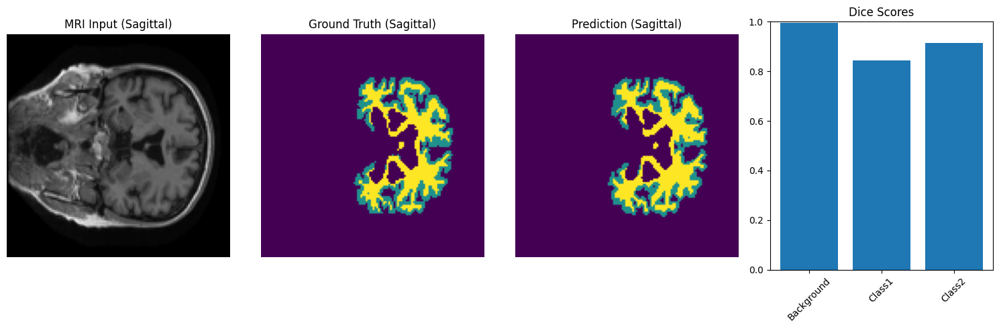

Case 1 Dice scores: ['0.996', '0.844', '0.916']


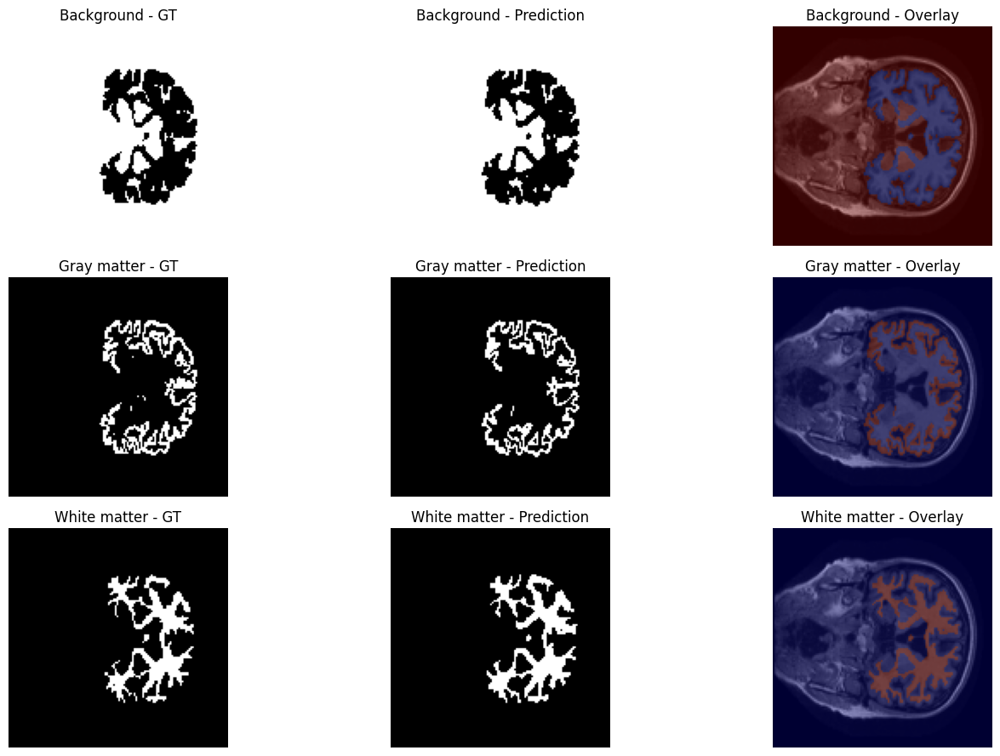

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


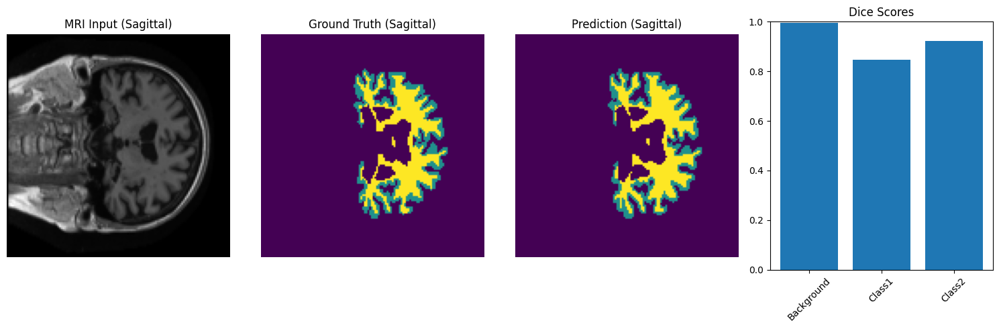

Case 2 Dice scores: ['0.997', '0.846', '0.922']


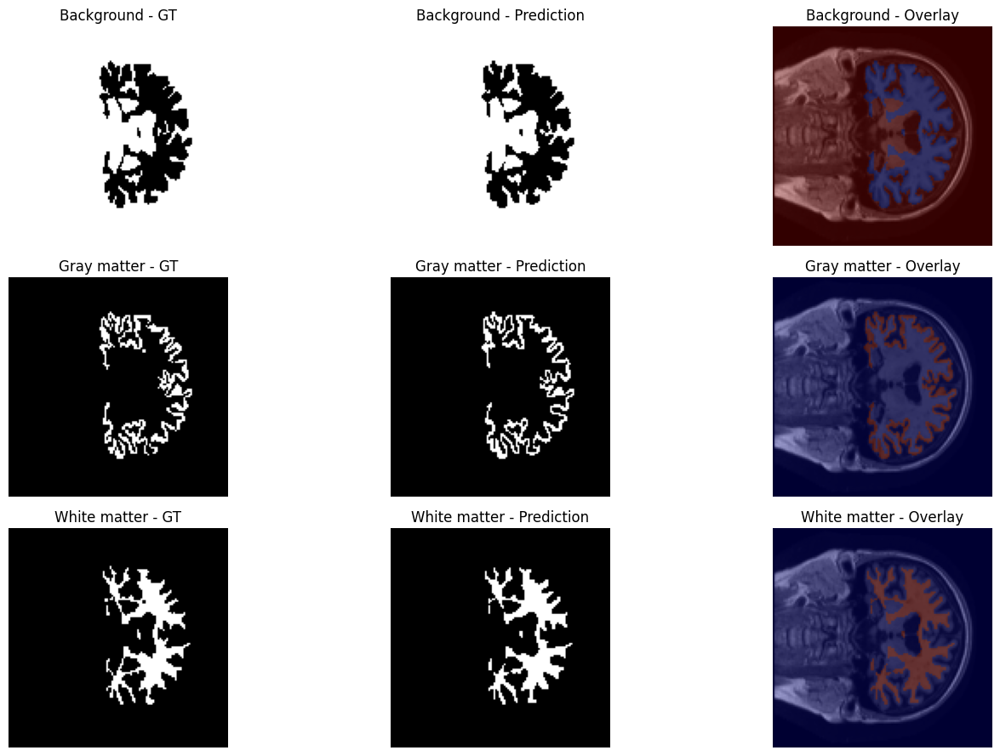

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


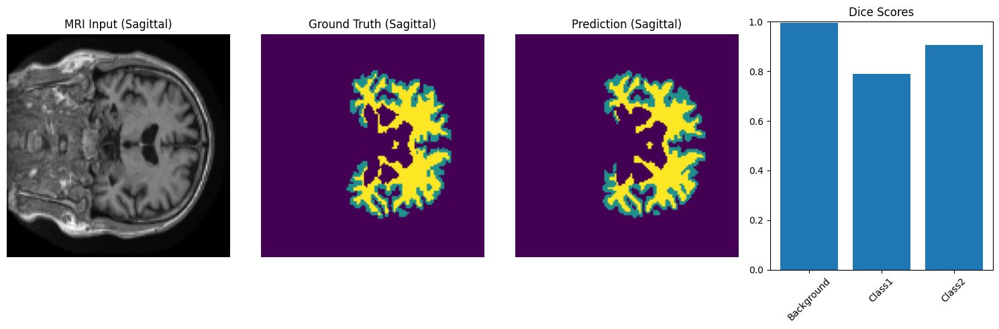

Case 3 Dice scores: ['0.995', '0.791', '0.905']


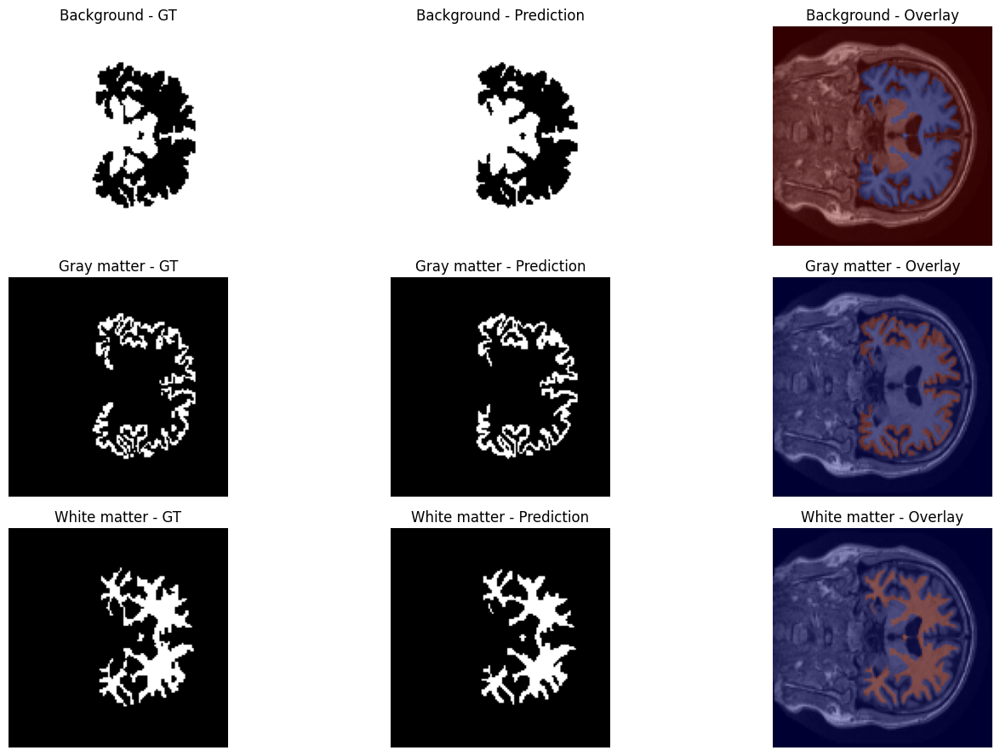

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


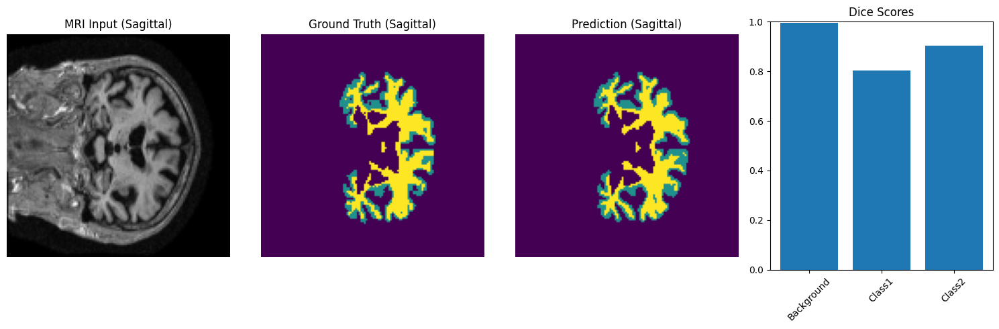

Case 4 Dice scores: ['0.996', '0.802', '0.904']


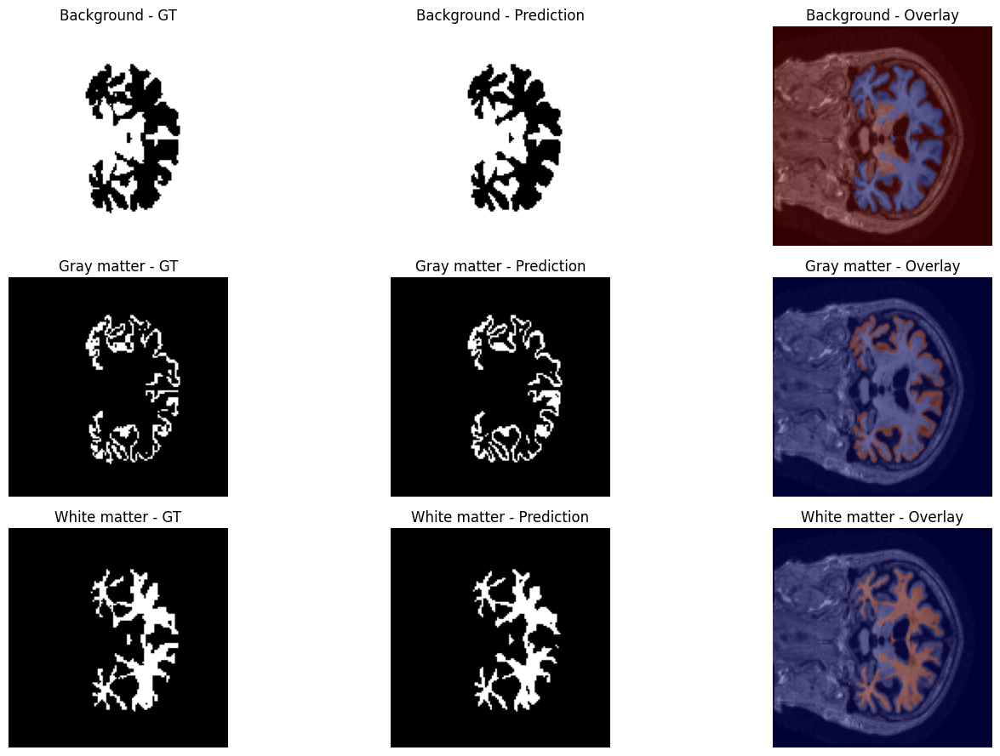

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


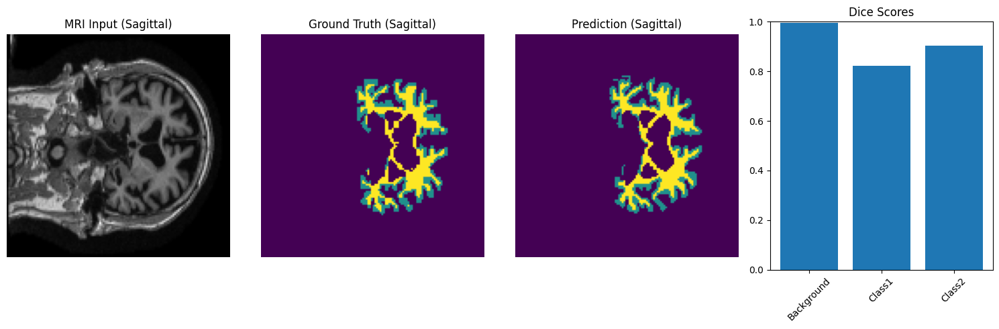

Case 5 Dice scores: ['0.997', '0.822', '0.905']


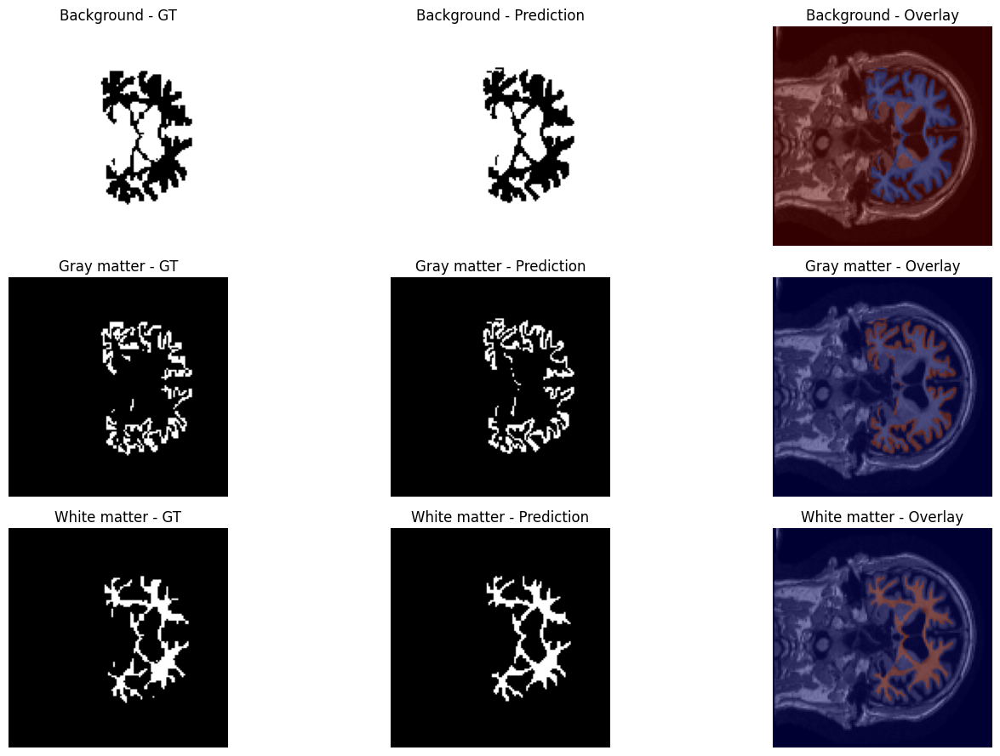

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


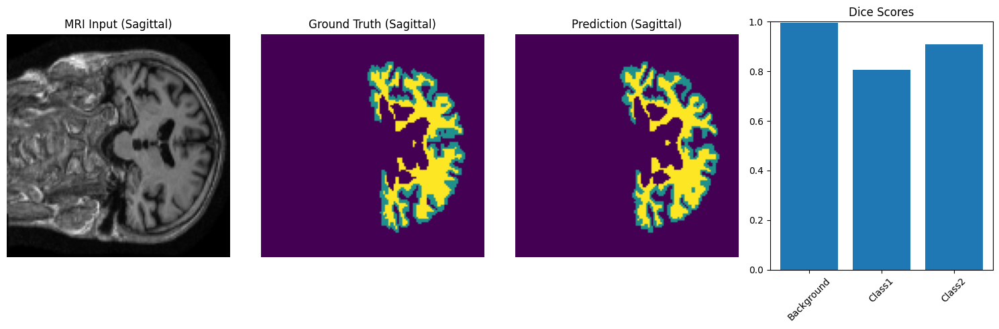

Case 6 Dice scores: ['0.995', '0.806', '0.910']


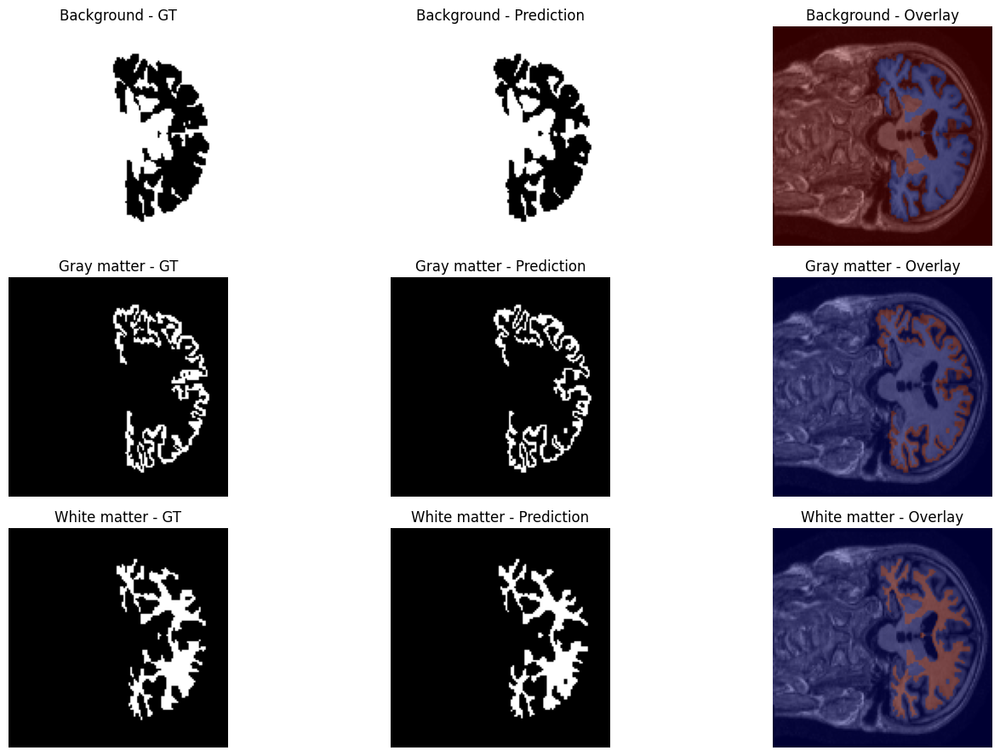

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


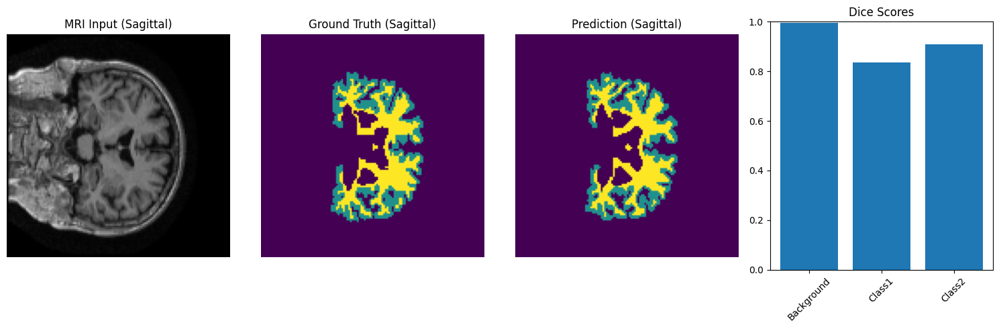

Case 7 Dice scores: ['0.996', '0.837', '0.908']


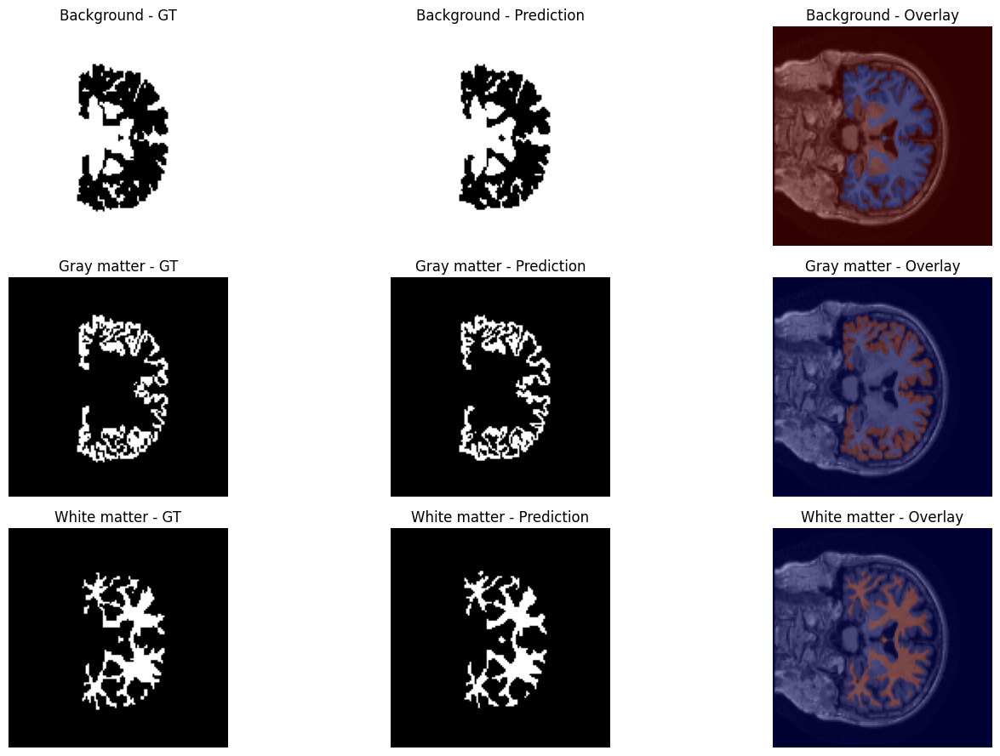

/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled_nii = resample_img(
/tmp/ipykernel_53298/2706419519.py:22: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled_nii = resample_img(


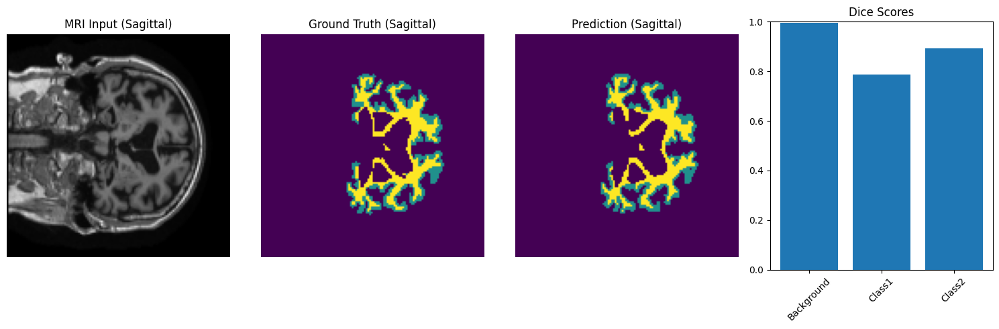

Case 8 Dice scores: ['0.996', '0.788', '0.893']


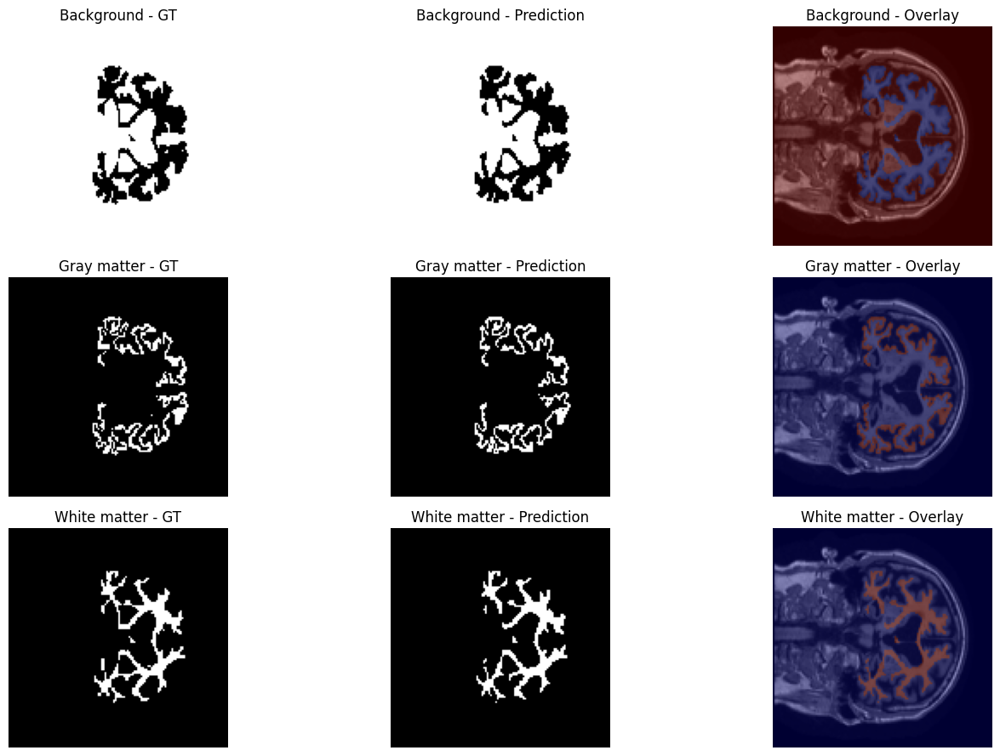

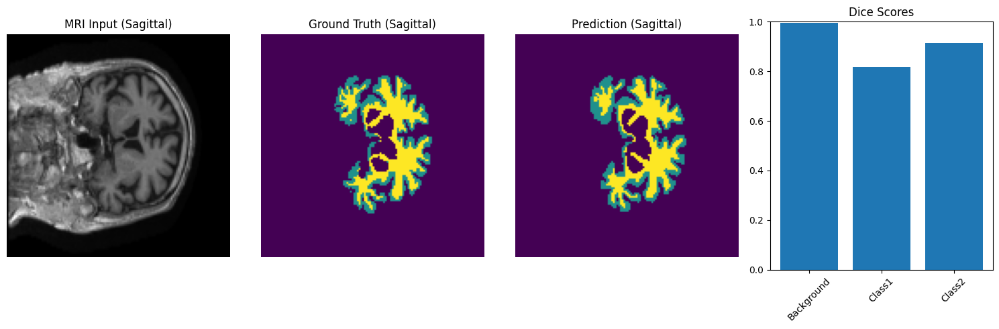

Case 9 Dice scores: ['0.997', '0.816', '0.914']


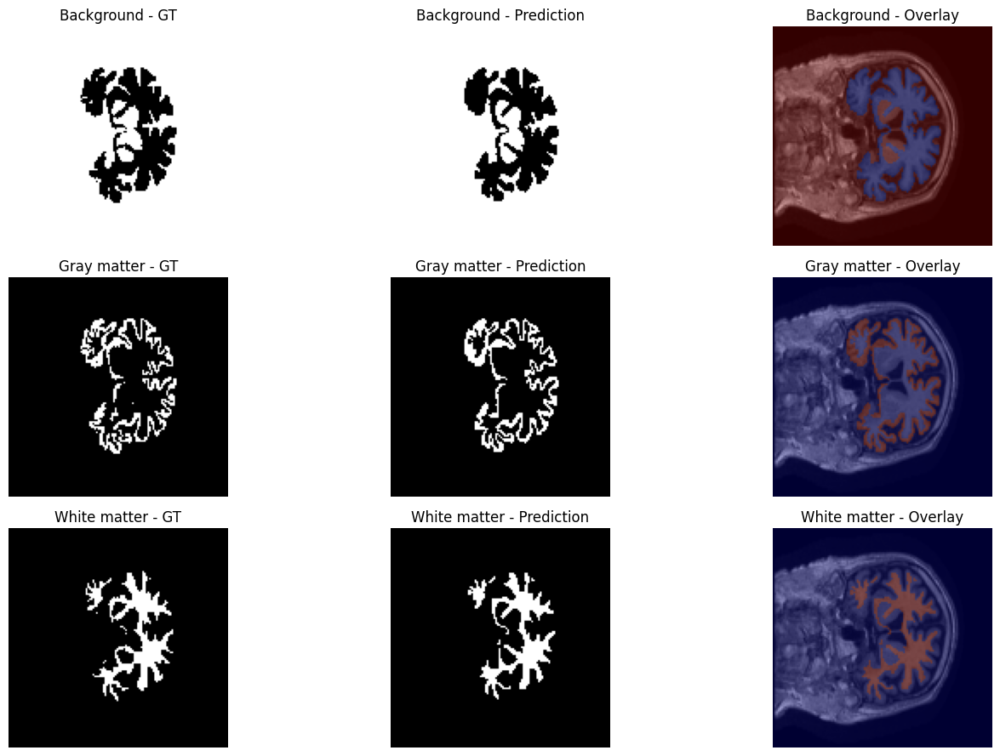

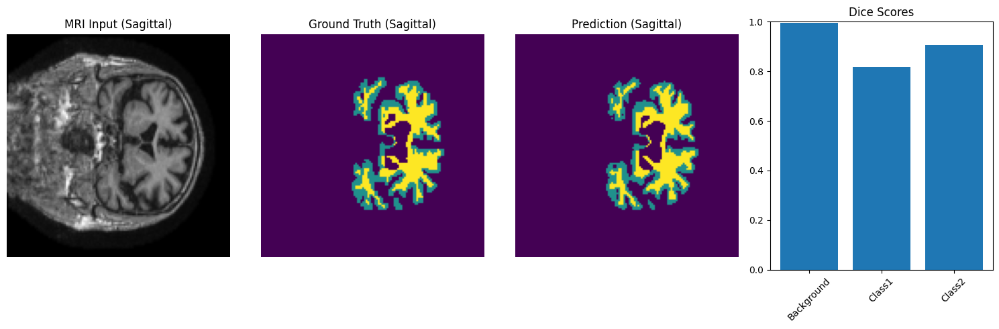

Case 10 Dice scores: ['0.996', '0.818', '0.907']


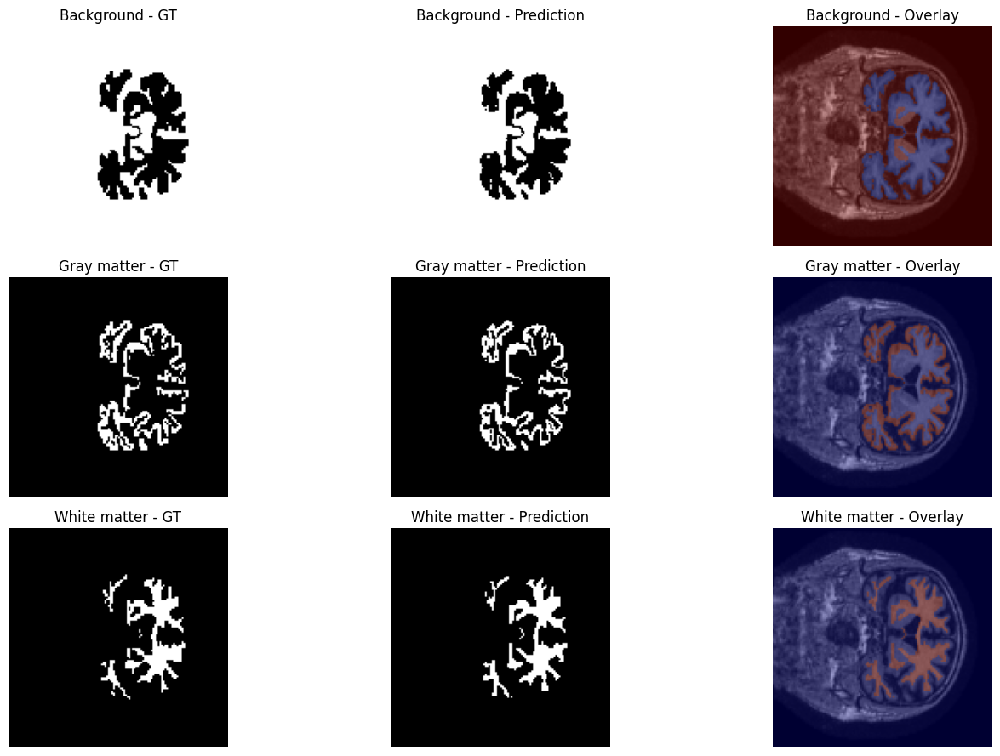

array([[0.99638559, 0.84358864, 0.9155326 ],
       [0.99678366, 0.84641737, 0.92225801],
       [0.99493767, 0.79071719, 0.90530384],
       [0.99609636, 0.80185482, 0.90428967],
       [0.99664033, 0.82154674, 0.90462245],
       [0.99520779, 0.80646725, 0.90981906],
       [0.99629267, 0.83687915, 0.90842275],
       [0.99552948, 0.78804166, 0.89326108],
       [0.99660564, 0.81570279, 0.91396611],
       [0.99639906, 0.81751202, 0.907383  ]])

In [ ]:
eval_on_dataset(test_dataset)